### Comparing ATE error with Interaction and Additive mechanism for `Revenue`
##### This notebook was ran with the current version of `PyCausalSim` not the proposed PR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import graphviz

from pycausalsim.models import StructuralCausalModel # Version 0.1.0

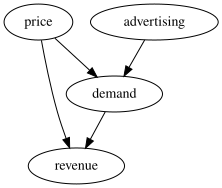

In [2]:
# Define a known causal graph
# Price -> Demand -> Revenue
# Advertising -> Demand
graph = {
    'revenue': ['demand', 'price'],
    'demand': ['price', 'advertising'],
    'price': [],
    'advertising': []
}

# Draw the graph inline
dot = graphviz.Digraph(comment='DGP Causal Graph')
for node in graph:
    dot.node(node)
# graph maps child -> [parents], so edges go parent -> child
for child, parents in graph.items():
    for parent in parents:
        dot.edge(parent, child)
        
dot  # renders inline as SVG


In [3]:
# Generate data according to this structure
np.random.seed(42)
n = 10000

# Root causes drawn from non-gaussian distributions
price = np.random.lognormal(np.log(6), 0.5, n)
advertising = np.random.laplace(50, 5, n)

# Intermediate variables
demand_fn = lambda price, advertising: np.clip(100 - price**2/3 + 0.5 * advertising + np.random.uniform(0, 100, n), 0, 500)
revenue_fn = lambda demand, price: np.clip(3 * price + 0.5 * demand +  np.random.exponential(1, n), 0, np.inf)
revenue_fn_inter = lambda demand, price: np.clip(0.1 * demand * price + np.random.exponential(1, n), 0, np.inf) # -> Interactions make it non-linear and GradientBoostingRegressor with depth 3 cannot model them accurately which translates into ATE error

demand = demand_fn(price, advertising)
revenue = revenue_fn(demand, price)

revenue_inter = revenue_fn_inter(demand, price)
graph_inter = {
    ('revenue_inter' if k == 'revenue' else k): list(v)
    for k, v in graph.items()
}


scm_data = pd.DataFrame({
    'price': price,
    'advertising': advertising, 
    'demand': demand,
    'revenue': revenue,
    'revenue_inter': revenue_inter
})


Text(0.5, 0, 'Revenue Inter')

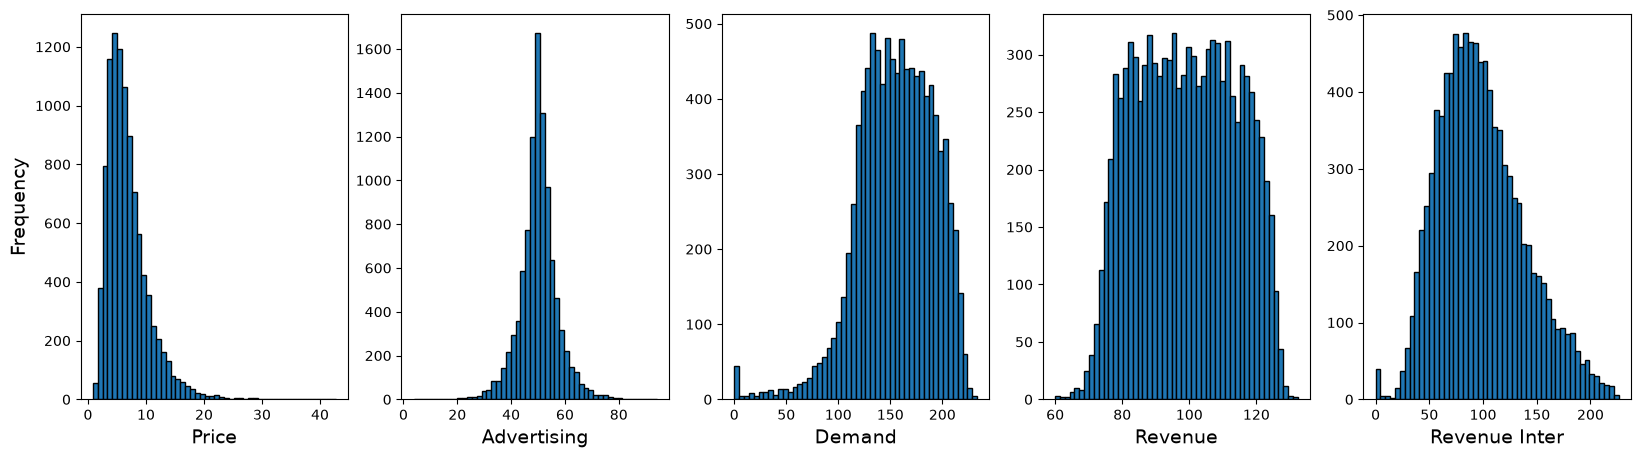

In [4]:
# Subplots for each variable distribution
BINS = 50
fig, axs = plt.subplots(1, 5, figsize=(20, 5))

# Price distribution
axs[0].hist(price, bins=BINS, edgecolor='black')
axs[0].set_xlabel('Price', fontsize=14) 
axs[0].set_ylabel('Frequency', fontsize=14)

# Advertising distribution
axs[1].hist(advertising, bins=BINS, edgecolor='black')
axs[1].set_xlabel('Advertising', fontsize=14)

# Demand distribution
axs[2].hist(demand, bins=BINS, edgecolor='black')
axs[2].set_xlabel('Demand', fontsize=14)

# Revenue distribution
axs[3].hist(revenue, bins=BINS, edgecolor='black')
axs[3].set_xlabel('Revenue', fontsize=14)

# Revenue Inter distribution
axs[4].hist(revenue_inter, bins=BINS, edgecolor='black')
axs[4].set_xlabel('Revenue Inter', fontsize=14)


In [8]:
# Fit SCM
df = scm_data.drop(columns=['revenue_inter'], inplace=False)
scm = StructuralCausalModel(graph=graph, noise_type='gaussian')
scm.fit(df)


df_inter = scm_data.drop(columns=['revenue'], inplace=False)
scm_inter = StructuralCausalModel(graph=graph_inter, noise_type='gaussian')
scm_inter.fit(df_inter)

StructuralCausalModel(variables=4, fitted=True)


--------------------------------------------------
Average Treatment Effect: Price Increase 4.50 --> 6.00
--------------------------------------------------


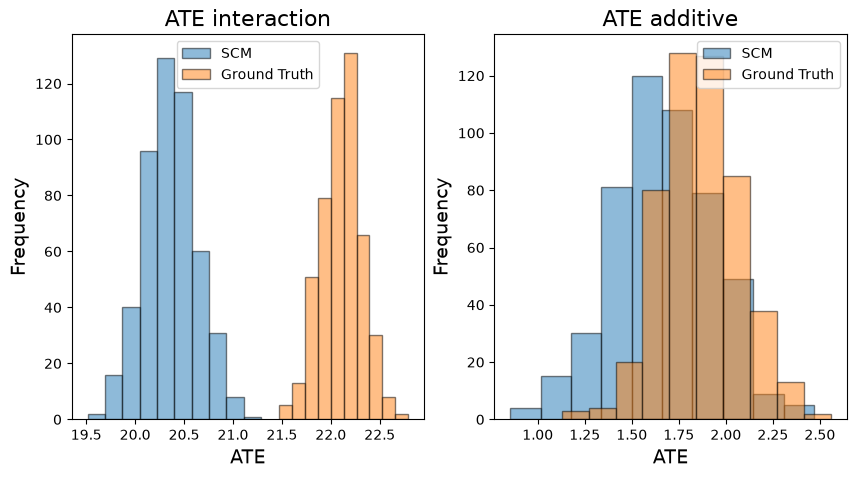

In [10]:
# Compute ATE for price increase

REF_PRICE = 4.5
T_PRICE = 6

print("\n" + "-" * 50)
print(f"Average Treatment Effect: Price Increase {REF_PRICE:.2f} --> {T_PRICE:.2f}")
print("-" * 50)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, (scm_model, rev_func) in enumerate([(scm, 'additive'), (scm_inter, 'interaction')][::-1]):

    scm_ate = []
    ate_gt = []

    for rep in range(500):
        scm_ate.append(scm_model.ate(
            treatment='price',
            outcome='revenue' if rev_func == 'additive' else 'revenue_inter',
            treatment_value=T_PRICE,
            control_value=REF_PRICE,
            n_samples=5000
        ))

        #Ground truth
        demand_0 = demand_fn(REF_PRICE, advertising)
        demand_1 = demand_fn(T_PRICE, advertising)

        revenue_0 = revenue_fn(demand_0, REF_PRICE) if rev_func == 'additive' else revenue_fn_inter(demand_0, REF_PRICE)
        revenue_1 = revenue_fn(demand_1, T_PRICE) if rev_func == 'additive' else revenue_fn_inter(demand_1, T_PRICE)

        ate_gt.append(np.mean(revenue_1 - revenue_0))


    # Plot overlaying distributions
    ax[i].hist(scm_ate, edgecolor='black', alpha=0.5, label=f'SCM')
    ax[i].hist(ate_gt, edgecolor='black', alpha=0.5, label='Ground Truth')
    ax[i].set_title(f'ATE {rev_func}', fontsize=16)
    ax[i].set_xlabel(f'ATE', fontsize=14)
    ax[i].set_ylabel('Frequency', fontsize=14)
    ax[i].legend()